In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim, mean_squared_error as mse
import copy

# Загрузка изображения

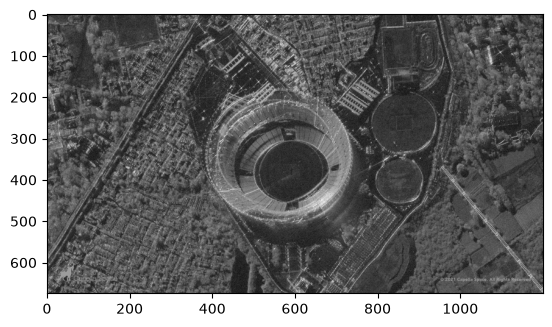

In [2]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray, cmap="gray")

# Шум Гаусса

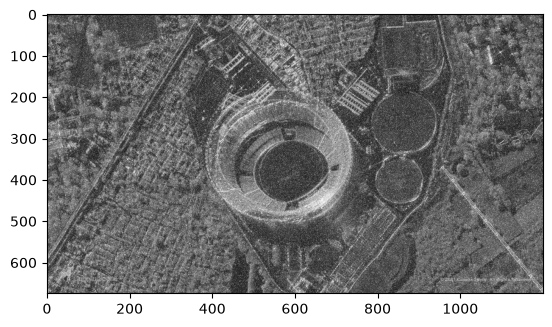

In [3]:
mean = 0
stddev = 50 
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image_gray, noise_gauss)

plt.imshow(image_noise_gauss, cmap="gray")

# Постянный шум

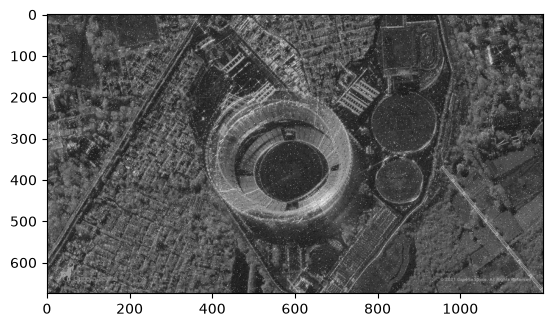

In [4]:
noise = np.random.randint(0, 101, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)   
ones_pixel = np.where(noise == 100)  

image_sp = copy.deepcopy(image_gray)
image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

plt.imshow(image_sp, cmap="gray")

In [5]:
mse_init_gauss = mse(image_gray, image_noise_gauss)
ssim_init_gauss = ssim(image_gray, image_noise_gauss)
print(f"Исходные MSE: {mse_init_gauss:.2f}, SSIM: {ssim_init_gauss:.4f}")

mse_init_sp = mse(image_gray, image_sp)
ssim_init_sp = ssim(image_gray, image_sp)
print(f"MSE: {mse_init_sp:.2f}, SSIM: {ssim_init_sp:.4f}\n")

Исходные MSE: 1239.24, SSIM: 0.4099
MSE: 387.40, SSIM: 0.7200



# Фильтры

In [6]:
def test_all_filters(noisy_image, clean_image):
    results = []

    # 1. Медианный фильтр 
    for k in [3, 5, 7]:
        filtered = cv2.medianBlur(noisy_image, k)
        MSE = mse(clean_image, filtered)
        SSIM = ssim(clean_image, filtered)
        results.append({
            "filter": "Median", 
            "params": f"ksize={k}", 
            "mse": MSE, "ssim": SSIM, 
            "image": filtered
        })

    # 2. Фильтр Гаусса 
    for ksize in [(3, 3), (5, 5), (7, 7)]:
        for sigma in [0, 1.0, 2.0]:
            filtered = cv2.GaussianBlur(noisy_image, ksize, sigma)
            MSE = mse(clean_image, filtered)
            SSIM = ssim(clean_image, filtered)
            results.append({
                "filter": "Gaussian", 
                "params": f"k={ksize}, sigma={sigma}", 
                "mse": MSE, "ssim": SSIM, 
                "image": filtered
            })

    # 3. Билатеральный фильтр 
    for d in [5, 9]:
        for sc, ss in [(50, 50), (75, 75), (100, 100)]:
            filtered = cv2.bilateralFilter(noisy_image, d, sc, ss)
            MSE = mse(clean_image, filtered)
            SSIM = ssim(clean_image, filtered)
            results.append({
                "filter": "Bilateral", 
                "params": f"d={d}, sc={sc}, ss={ss}", 
                "mse": MSE, "ssim": SSIM, 
                "image": filtered
            })

    # 4. Фильтр нелокальных средних 
    for h in [25, 30, 35, 40, 50]:
        filtered = cv2.fastNlMeansDenoising(noisy_image, h=h)
        MSE = mse(clean_image, filtered)
        SSIM = ssim(clean_image, filtered)
        results.append({
            "filter": "NL-Means", 
            "params": f"h={h}", 
            "mse": MSE, "ssim": SSIM, 
            "image": filtered
        })

    results.sort(key=lambda item: item["mse"])
    return results

--- ТЕСТИРОВАНИЕ НА ГАУССОВОМ ШУМЕ ---
[Median] ksize=3 -> MSE: 376.45, SSIM: 0.6355
[Median] ksize=5 -> MSE: 378.74, SSIM: 0.5689
[Median] ksize=7 -> MSE: 424.57, SSIM: 0.4859
[Bilateral] d=5, sc=75, ss=75 -> MSE: 506.40, SSIM: 0.6463
[Bilateral] d=5, sc=100, ss=100 -> MSE: 515.84, SSIM: 0.6485
[Bilateral] d=9, sc=75, ss=75 -> MSE: 535.17, SSIM: 0.5819
[Bilateral] d=9, sc=50, ss=50 -> MSE: 551.17, SSIM: 0.5683
[Gaussian] k=(5, 5), sigma=1.0 -> MSE: 567.71, SSIM: 0.6684
[NL-Means] h=25 -> MSE: 567.81, SSIM: 0.5809
[Gaussian] k=(7, 7), sigma=1.0 -> MSE: 567.93, SSIM: 0.6672
[Bilateral] d=9, sc=100, ss=100 -> MSE: 569.76, SSIM: 0.5557
[Gaussian] k=(5, 5), sigma=0 -> MSE: 570.35, SSIM: 0.6624
[Bilateral] d=5, sc=50, ss=50 -> MSE: 570.74, SSIM: 0.5919
[Gaussian] k=(3, 3), sigma=1.0 -> MSE: 576.60, SSIM: 0.6652
[Gaussian] k=(3, 3), sigma=0 -> MSE: 580.36, SSIM: 0.6659
[Gaussian] k=(3, 3), sigma=2.0 -> MSE: 585.13, SSIM: 0.6467
[Gaussian] k=(7, 7), sigma=0 -> MSE: 594.41, SSIM: 0.6163
[NL-Me

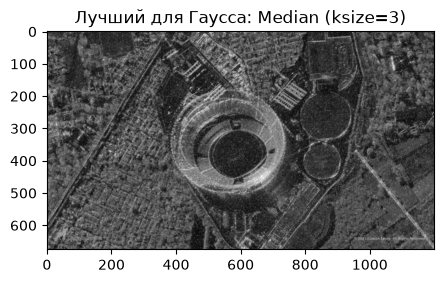

--- ТЕСТИРОВАНИЕ НА ПОСТОЯННОМ ШУМЕ ---
[Median] ksize=3 -> MSE: 95.70, SSIM: 0.8163
[Gaussian] k=(3, 3), sigma=0 -> MSE: 121.33, SSIM: 0.7835
[Gaussian] k=(3, 3), sigma=1.0 -> MSE: 125.35, SSIM: 0.7726
[Gaussian] k=(5, 5), sigma=1.0 -> MSE: 136.12, SSIM: 0.7479
[Gaussian] k=(7, 7), sigma=1.0 -> MSE: 138.01, SSIM: 0.7441
[Gaussian] k=(3, 3), sigma=2.0 -> MSE: 140.16, SSIM: 0.7417
[Gaussian] k=(5, 5), sigma=0 -> MSE: 142.50, SSIM: 0.7349
[Bilateral] d=5, sc=100, ss=100 -> MSE: 173.31, SSIM: 0.6821
[Gaussian] k=(7, 7), sigma=0 -> MSE: 182.46, SSIM: 0.6595
[Gaussian] k=(5, 5), sigma=2.0 -> MSE: 191.54, SSIM: 0.6406
[Median] ksize=5 -> MSE: 193.98, SSIM: 0.6333
[Gaussian] k=(7, 7), sigma=2.0 -> MSE: 221.09, SSIM: 0.5889
[NL-Means] h=25 -> MSE: 232.84, SSIM: 0.5310
[Bilateral] d=9, sc=100, ss=100 -> MSE: 239.13, SSIM: 0.5339
[Median] ksize=7 -> MSE: 260.01, SSIM: 0.5225
[Bilateral] d=5, sc=75, ss=75 -> MSE: 260.96, SSIM: 0.6380
[Bilateral] d=9, sc=75, ss=75 -> MSE: 265.71, SSIM: 0.5195
[NL-

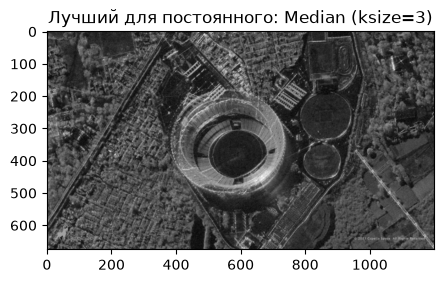

In [7]:
print("--- ТЕСТИРОВАНИЕ НА ГАУССОВОМ ШУМЕ ---")
res_gauss = test_all_filters(image_noise_gauss, image_gray)
best_gauss = res_gauss[0]
for r in res_gauss:
    print(f"[{r['filter']}] {r['params']} -> MSE: {r['mse']:.2f}, SSIM: {r['ssim']:.4f}")

print(f"\n>> ЛУЧШИЙ: {best_gauss['filter']} ({best_gauss['params']})\n")

plt.figure(figsize=(5, 5))
plt.title(f"Лучший для Гаусса: {best_gauss['filter']} ({best_gauss['params']})")
plt.imshow(best_gauss['image'], cmap="gray")
plt.show()

print("--- ТЕСТИРОВАНИЕ НА ПОСТОЯННОМ ШУМЕ ---")
res_sp = test_all_filters(image_sp, image_gray)
best_sp = res_sp[0]
for r in res_sp: 
    print(f"[{r['filter']}] {r['params']} -> MSE: {r['mse']:.2f}, SSIM: {r['ssim']:.4f}")

print(f"\n>> ЛУЧШИЙ: {best_sp['filter']} ({best_sp['params']})\n")

plt.figure(figsize=(5, 5))
plt.title(f"Лучший для постоянного: {best_sp['filter']} ({best_sp['params']})")
plt.imshow(best_sp['image'], cmap="gray")
plt.show()